# Kunskapskontroll 1 – AI: Teori och tillämpning
**Kurs:** AI och Maskininlärning  
**Inlämning:** Kunskapskontroll Del 1  
**Kursbok:** *Lär dig AI från grunden – Tillämpad maskininlärning med Python* (Antonio Prgomet)  

---

### Innehållsförteckning
1. **Kapitel 1:** Introduktion till maskininlärning (Fråga 1–9, 11)
2. **Kapitel 2:** Ett ML-projekt från början till slut (Fråga 1–6, 8–12)
3. **Kapitel 3:** Regression (Fråga 1–11, 13, 16)
4. **Kapitel 4:** Klassificering (Fråga 1–9, 11, 13, 15)
5. **Kapitel 5:** Dimensionsreducering (Fråga 1–3, 5–6, 8–9)
6. **Kapitel 6:** Klustring (Fråga 1–2, 3–5, 7, 9)

---


In [1]:
# Grundläggande bibliotek och inställningar
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Tysta eventuella varningar för renare redovisning
warnings.filterwarnings('ignore')

# Enhetlig och stilren visualisering
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 10

print("Miljö initierad och alla bibliotek inlästa.")


Miljö initierad och alla bibliotek inlästa.


# Kapitel 1 – Introduktion till maskininlärning

## Faktafrågor


### Fråga 1: Hur hänger AI, ML och DL ihop?

Det enklaste sättet att se relationen är som tre lager:

* **AI (Artificiell intelligens)** är det stora paraplybegreppet för all teknik som får datorer att verka intelligenta eller lösa problem som normalt kräver mänsklig tankekraft. Det täcker allt från gamla regelbaserade system och schackdatorer till moderna algoritmer.
* **ML (Maskininlärning)** är en delmängd av AI där vi slutar hårdkoda explicita regler. Istället matar vi datorn med data och låter algoritmen själv upptäcka statistiska samband för att dra slutsatser om ny data.
* **DL (Djupinlärning)** är i sin tur en specialiserad del av ML som bygger på djupa neurala nätverk med många lager. Det revolutionerande med DL är att nätverket självt klarar av att plocka ut relevanta mönster direkt ur rå och ostrukturerad data (som bilder, ljud och text) utan att vi behöver sitta och skapa variabler för hand.

Kort sagt: all djupinlärning är ML, och all ML är AI – men AI är mycket bredare än bara neurala nätverk.


### Fråga 2: Vilka är de fyra problemkategorierna inom ML?

Det kokar i grunden ner till om vi har en känd målvariabel ($y$, facit) eller inte:

1. **Regression (väglett lärande):** När målet är att förutsäga ett numeriskt tal. Typ vad en bostad kommer säljas för, morgondagens elpris eller temperaturen i helgen.
2. **Klassificering (väglett lärande):** När svaret är en kategori eller etikett. Kan vara två alternativ (spam eller inte spam, bedrägeri eller legitimt köp) eller fler (klassificera fordon som bil, buss eller cykel).
3. **Dimensionsreducering (icke-väglett lärande):** När man har alldeles för många kolumner och vill banta ner datamängden (t.ex. med PCA) för att snabba upp beräkningar eller visualisera i 2D/3D, utan att tappa den viktiga informationen.
4. **Klustring (icke-väglett lärande):** När algoritmen själv får leta upp naturliga grupper i datan utifrån vilka observationer som liknar varandra, t.ex. när man delar in kunder i olika segment baserat på köpvanor.

Regression och klassificering är väglett lärande eftersom vi har ett facit att rätta modellen mot. Dimensionsreducering och klustring är icke-väglett eftersom det inte finns något facit, utan algoritmen får klura ut strukturerna i datan på egen hand.


### Fråga 3: Förklaring av grundläggande koncept (a–h)

#### a) Syftet med träningsdata, valideringsdata och testdata
- **Träningsdata:** Det modellen faktiskt pluggar på för att anpassa sina parametrar (t.ex. vikter).
- **Valideringsdata:** Används under utvecklingen för att jämföra olika modeller och skruva på hyperparametrar.
- **Testdata:** Låses in och rörs inte förrän i absolut sista sekund för att ge ett ärligt kvitto på om modellen faktiskt klarar ny, osedd data.

#### b) Vad är k-delad korsvalidering?
Istället för att bara göra en enda chansartad split delar man upp träningsdatan i $k$ bitar (ofta 5 eller 10). Modellen tränas på $k-1$ bitar och utvärderas på den sista, och så snurrar man runt så att varje bit får agera test en gång. Man får ett mycket stabilare mått på prestandan och slipper oroa sig för att en slumpmässig split gav en skev bild.

#### c) Vad är Root Mean Squared Error (RMSE)?
$$\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2}$$
Standardmåttet för hur fel en regressionsmodell gissar i snitt. Man tar felen, kvadrerar dem (vilket straffar rejäla missar extra hårt), tar medelvärdet och drar roten ur. Roten gör att felet hamnar i samma enhet som det man försöker förutsäga – gissar man löner får man felet direkt i kronor.

#### d) Hyperparameter vs Parameter
- **Parameter:** Det modellen själv lär sig och räknar fram ur datan under träningen (t.ex. lutning och intercept i linjär regression).
- **Hyperparameter:** Inställningarna vi utvecklare bestämmer manuellt *innan* träningen startar, som styr hur modellen ska lära sig (t.ex. hur djupt ett beslutsträd får växa).

#### e) Grid Search och vad `refit=True` innebär
- **Grid Search:** Man sätter upp en lista med inställningar man vill testa, och så testar datorn systematiskt varenda kombination med korsvalidering för att hitta den bästa.
- **`refit=True`:** När den bästa kombinationen hittats tränar scikit-learn automatiskt om vinnarmodellen på precis all träningsdata, så man direkt har en färdig modell som utnyttjar 100% av datan.

#### f) Kategorisk data och hur det hanteras
- **Nominal data:** Saknar inbördes ordning (t.ex. bilmärken eller färger). Görs om med dummy-kodning eller one-hot encoding. Vid linjära modeller kör man `drop_first=True` för att slippa multikollinearitet (*dummy variable trap*).
- **Ordinal data:** Har en naturlig rangordning (t.ex. utbildning: grundskola, gymnasium, universitet). Här mappar man bara kategorierna till ordnade siffror (1, 2, 3) så ordningen bevaras.

#### g) Vad är Feature Engineering?
Att använda sunt förnuft och domänkunskap för att ge modellen bättre förutsättningar. Det kan handla om att kombinera kolumner till smartare variabler (som att dela boarea med antal rum för att få snittyta per rum), logga skeva fördelningar eller skala om variablerna så alla ligger på samma nivå.

#### h) Principle of Parsimony (Ockhams rakkniv)
Om två modeller presterar ungefär lika bra ska man alltid välja den enklare modellen. Krångla inte till det med ett jättenätverk om en linjär regression löser uppgiften. Enklare modeller överanpassar mer sällan, drar mindre resurser och är faktiskt begripliga att förklara för andra.


### Fråga 4: Vad innebär det att en modell är en förenkling av verkligheten?

Verkligheten styrs av alldeles för många faktorer för att någon matematisk formel någonsin ska kunna pricka in allt. Om en modell försökte fånga varenda mikroskopisk detalj skulle den bara snöa in på rent slumpbrus. 

Hela poängen med en modell är just att skala bort bruset och plocka ut de stora, systematiska sambanden som faktiskt spelar roll. Som det klassiska uttrycket inom statistiken lyder: alla modeller har fel i teorin, men i praktiken är de ändå grymt användbara. En förenkling är inte ett misslyckande – det är hela förutsättningen för att modellen ska fungera på ny data.


### Fråga 5: Vad är överanpassning (overfitting) och varför uppstår det?

Överanpassning är när modellen blir som en student som pluggat in gamla tentor utantill ord för ord istället för att fatta själva ämnet. Den får 100 % rätt på övningstentan (träningsdatan), men när den ställs inför en ny fråga på den riktiga tentan (ny, osedd data) blir det pannkaka.

Det uppstår när modellen är för komplex i förhållande till mängden data man har – den börjar lära sig träningsdatans slumpmässiga brus och egenheter istället för de verkliga sambanden.


### Fråga 6: Konventionen "högre är bättre" i scikit-learn

Scikit-learn är designat så att alla sök- och optimeringsverktyg (som `GridSearchCV`) alltid försöker maximera ett poängvärde – ju högre siffra, desto bättre modell.

För mått som $R^2$ eller träffsäkerhet är det ju självklart. Men för rena felmått som MSE (där 0 är bäst och högre värden är dåliga) vänder scikit-learn helt enkelt på steken och sätter ett minustecken framför (`neg_mean_squared_error`). Ett litet fel på 5 blir då -5, och ett stort fel på 20 blir -20. Eftersom -5 är ett "större" tal än -20 funkar samma maximeringslogik rakt av utan specialregler.


### Fråga 7: Skillnaden mellan tvärsnittsdata, tidsseriedata och paneldata

- **Tvärsnittsdata:** Många olika observationer mätta vid ett enda tillfälle.  
  *Exempel:* Slutpriser på 500 bostäder som såldes i Göteborg under maj 2024.
- **Tidsseriedata:** En och samma sak som följs över tid i kronologisk ordning.  
  *Exempel:* Dagskursen för en aktie under de senaste tre åren.
- **Paneldata:** En kombo av båda – flera olika observationer som följs över flera tidpunkter.  
  *Exempel:* Omsättning och resultat för 50 olika bolag, mätt kvartalsvis under fem års tid.


### Fråga 8: Tre tillämpningsområden för maskininlärning

1. **Stoppa kortbedrägerier:** Bank- och betaltjänster som scannar kortköp i realtid och automatiskt flaggar transaktioner som avviker från hur användaren brukar handla.
2. **Medicinsk bildanalys:** Modeller som analyserar röntgen- och MR-bilder för att upptäcka tidiga tumörer eller frakturer snabbare och säkrare än det mänskliga ögat.
3. **Rekommendationssystem:** Algoritmerna bakom Spotify och Netflix som analyserar vad man lyssnat eller tittat på för att föreslå nytt innehåll som träffar rätt.


### Fråga 9: Varför returneras negativa värden för `neg_mean_squared_error` i scikit-learn?

MSE mäter hur mycket modellen felar, så vanliga MSE-värden är alltid positiva där 0 är perfekt och höga tal är dåligt. 

Men eftersom scikit-learn konsekvent vill maximera score (se fråga 6), multipliceras värdet med $-1$:
$$\text{neg\_mean\_squared\_error} = -\text{MSE}$$

Då blir det lägsta felet till det minst negativa (dvs. högsta) talet. På så sätt kan optimeraren bara leta efter det högsta värdet och automatiskt pricka in modellen med lägst fel.


### Fråga 11 (Kodfråga): Matematisk förklaring till 60-20-20 fördelningen

Matematiken bakom koden är enkel när man bryter ner den:

1. Först sätter `test_size=0.2` av $20\%$ av hela datasetet till testdata. Då återstår $80\%$ som träningspool (`train_full`).
2. Sedan delas träningspoolen med `test_size=0.25`. Här tas alltså $25\%$ av de kvarvarande $80\%$ till validering:
$$0.25 \times 0.80 = 0.20 \quad (20\%)$$
3. Kvar i den faktiska träningsmängden blir:
$$80\% - 20\% = 60\%$$

Det ger precis fördelningen **60 % träning, 20 % validering och 20 % test**.


In [2]:
# Verifiering av fråga 11
from sklearn.model_selection import train_test_split

# Skapa ett syntetiskt dataset med 1 000 observationer
X_dummy = np.random.randn(1000, 4)
y_dummy = np.random.randn(1000)

# Steg 1: 20% testdata -> 80% kvar
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_dummy, y_dummy, test_size=0.2, random_state=42
)

# Steg 2: 25% av resterande 80% till validering -> 20% totalt
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42
)

total = len(X_dummy)
print(f"Total mängd observationer: {total} (100%)")
print(f"Träningsdata:              {len(X_train)} ({len(X_train)/total*100:.0f}%)")
print(f"Valideringsdata:           {len(X_val)} ({len(X_val)/total*100:.0f}%)")
print(f"Testdata:                  {len(X_test)} ({len(X_test)/total*100:.0f}%)")


Total mängd observationer: 1000 (100%)
Träningsdata:              600 (60%)
Valideringsdata:           200 (20%)
Testdata:                  200 (20%)


# Kapitel 2 – Ett ML-projekt från början till slut

## Fakta- och kodfrågor


### Fråga 1: De sju stegen i ML-checklistan och processens icke-linjära natur

I teorin radar checklistan upp sju prydliga steg:
1. Förstå problemet och affärsmålet
2. Samla in datan
3. Utforska datan (EDA)
4. Tvätta och förbereda datan
5. Bygga och finjustera modeller
6. Presentera resultatet för verksamheten
7. Driftsätta och övervaka

**Varför processen inte är linjär:**  
I verkligheten är det absolut inget löpande band. Det är snarare en cirkel eller en bergochdalbana. När man väl börjar bygga modeller (steg 5) upptäcker man nästan alltid skumma fel eller konstigheter i resultatet som tvingar en tillbaka till datatvätten (steg 4) eller ny datautforskning (steg 3). Man hoppar fram och tillbaka i kontinuerliga feedback-loopar hela tiden.


### Fråga 2: Vad innebär produktionssättning och varför är övervakning viktigt?

- **Produktionssättning (Deployment):** Att flytta modellen från sin trygga lilla Jupyter notebook på laptopen och driftsätta den i ett riktigt IT-system (t.ex. bakom ett REST-API eller i ett nattligt batchjobb), så att den faktiskt kan ta emot skarp data och göra nytta på riktigt.
- **Övervakning (Monitoring):** Världen förändras hela tiden. Kundbeteenden skiftar och inkommande data driver iväg (*data drift*). Har man ingen övervakning märker man inte när modellen långsamt börjar gissa sämre och sämre förrän det redan kostat pengar. Övervakningen larmar så fort träffsäkerheten dippar så att man kan träna om modellen på färsk data.


### Fråga 3: Scikit-learns designprinciper och grundläggande objekt

Scikit-learn är väldigt konsekvent och snyggt uppbyggt: alla modeller använder samma metoder, alla skattade värden sparas med ett understreck i slutet (`coef_`, `intercept_`), och man slipper konstiga specialklasser eftersom allt bygger på vanliga NumPy-arrays och DataFrames.

De tre kärnbitarna är:
1. **Estimators:** Alla objekt som kan lära sig ur data via `.fit(X, [y])` (både modeller och skalare).
2. **Transformers:** Objekt som bearbetar och ändrar om datan via `.transform(X)` (eller smidiga `.fit_transform(X)`), t.ex. `StandardScaler` eller imputers för saknade värden.
3. **Predictors:** Modellerna som gör förutsägelser på ny data via `.predict(X)`, t.ex. `LinearRegression` eller `RandomForest`.


### Fråga 4: Vad är TensorFlow och Keras och hur förhåller de sig till varandra?

Ett bra sätt att se det på är att **TensorFlow är motorn** under huven som sköter de tunga matrisberäkningarna på grafikkortet, medan **Keras är ratten och instrumentbrädan**.

TensorFlow i sig är ganska komplext och lågnivå. Keras fungerar som det smidiga Python-lagret ovanpå (som numera är standard via `tf.keras`) där man snabbt och modulärt kan bygga och träna neurala nätverk lager för lager utan att drunkna i krångliga detaljer.


### Fråga 5: Kalle och Stinas diskussion om testdata

**Stina har 100 % rätt här.**

Kalle fuskar i princip utan att ens fatta det själv. Testdatans enda syfte är att simulera framtiden – data som modellen aldrig någonsin har sett. 

Om Kalle sitter och kikar på testresultatet, ändrar en hyperparameter, kollar testet igen och loopar på det sättet, då läcker information från testsetet in i modellbygget (*data leakage / data snooping*). Till slut har han omedvetet skräddarsytt modellen för just de specifika testraderna, vilket ger en falskt förskönad bild. Han borde ha använt ett valideringsset eller korsvalidering för att labba fram inställningarna och sparat testsetet helt orört till absolut sista steget.


### Fråga 6: Utmaningar i praktiska ML-projekt – AI-hypen möter verklighetens datakvalitet

Det här är den absolut vanligaste krocken i branschen:

1. **AI-hypen och orealistiska förväntningar:**  
   Ledningsgrupper läser om AI och tror att det är ett magiskt trollspö som kan lösa alla företagets problem över en natt. Projekt startas med inställningen att "vi måste använda AI!" utan att man ens definierat vad problemet egentligen är eller om ML ens är rätt verktyg. Det skapar orimliga förväntningar och leder ofta till att man överkomplicerar lösningar där enkla regler eller baslinjer hade räckt.

2. **Verklighetens bristfälliga datakvalitet:**  
   I skolan får man färdigstädade CSV-filer serverade. I ett riktigt företag är datan nästan alltid en total soppa – utspridd i gamla silos, full av felvärden, bristfälligt loggad eller med massor av saknade fält. Gammal hederlig *"garbage in, garbage out"* gäller i allra högsta grad: stoppar man in skräpdata spelar det ingen roll hur häftig modell man har.

**Resultatet i praktiken:**  
Krocken gör att upp mot 80–90 % av arbetstiden tvingas läggas på tråkig datatvätt och rörig infrastruktur istället för roligt modellbygge. När ledningen inser att deras magiska AI kräver månader av grundarbete med databaser tröttnar de ofta, och projektet slutar som ännu en prototyp på "PoC-kyrkogården" istället för att nå skarp produktion.


### Fråga 8 (Koduppgift): Spara och ladda modeller med joblib

Att träna en maskininlärningsmodell på stora datamängder kan ta rejält med tid och datorkraft. Genom att spara modellens tillstånd (dess tränade vikter och parametrar) till disk med `joblib` kan vi i en produktionsmiljö ladda in den färdiga modellen på några millisekunder och generera prediktioner direkt utan att någonsin behöva träna om från början.


In [3]:
# Fråga 8: Spara och ladda modeller med joblib
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from joblib import dump, load

# 1. Generera syntetisk data och träna en modell
X_syn, y_syn = make_regression(n_samples=1000, n_features=3, noise=0.1, random_state=42)
lr_model = LinearRegression().fit(X_syn, y_syn)

# 2. Spara den tränade modellen till disk
dump(lr_model, "linear_model.joblib")
print("Modellen har sparats till filen 'linear_model.joblib'.")

# 3. Ladda in den sparade modellen
loaded_model = load("linear_model.joblib")
print("Modellen laddades in framgångsrikt från disk.")

# 4. Generera prediktioner med den inladdade modellen
sample_preds = loaded_model.predict(X_syn[:5])
print("\nPrediktioner för de fem första observationerna:")
for idx, val in enumerate(sample_preds, 1):
    print(f"  Observation {idx}: {val:.4f}")


Modellen har sparats till filen 'linear_model.joblib'.
Modellen laddades in framgångsrikt från disk.

Prediktioner för de fem första observationerna:
  Observation 1: -103.5994
  Observation 2: -57.3069
  Observation 3: -32.7023
  Observation 4: -17.9548
  Observation 5: 24.2066


### Fråga 9 (Koduppgift): Steg-för-steg modellering av `data_01.csv` (a–h)

Här genomför vi hela modellflödet:
- **a)** Läs in `data/data_01.csv`.
- **b)** Dela upp i $X$ (oberoende variabler) och $y$ (målvariabel).
- **c)** Dela upp i träning (68%), validering (12%) och test (20%) via en 80/20-split följt av en 85/15-split.
- **d)** Träna `LinearRegression` och `DecisionTreeRegressor` på träningsdatan.
- **e)** Utvärdera båda med RMSE på valideringsdatan och välj den bästa.
- **f)** Träna om vinnande modell på tränings- och valideringsdata tillsammans.
- **g)** Utvärdera den omtränade modellen på testdatan.
- **h)** Träna om modellen på hela datasetet (100%) inför skarp driftsättning.


In [4]:
# Fråga 9: Genomförande av steg a–h på data_01.csv
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import root_mean_squared_error

# a) Läs in datasetet
df_01 = pd.read_csv("data/data_01.csv")
print(f"Datasetets dimensioner: {df_01.shape}")
display(df_01.head(3))

# b) Dela upp i X och y (y är sista kolumnen)
X_01 = df_01.iloc[:, :-1]
y_01 = df_01.iloc[:, -1]

# c) Dela upp i train, validering och test (20% test, sedan 15% validering av återstående 80%)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_01, y_01, test_size=0.20, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=42
)
print(f"Träning: {len(X_train)} rader, Validering: {len(X_val)} rader, Test: {len(X_test)} rader")

# d) Träna LinearRegression och DecisionTreeRegressor på träningsdata
lr = LinearRegression().fit(X_train, y_train)
dt = DecisionTreeRegressor(max_depth=4, random_state=42).fit(X_train, y_train)

# e) Utvärdera på valideringsdata med RMSE
rmse_lr_val = root_mean_squared_error(y_val, lr.predict(X_val))
rmse_dt_val = root_mean_squared_error(y_val, dt.predict(X_val))

print(f"\nValiderings-RMSE:")
print(f"  Linjär Regression: {rmse_lr_val:.4f}")
print(f"  Beslutsträd:      {rmse_dt_val:.4f}")

# Välj bästa modell
if rmse_lr_val < rmse_dt_val:
    best_model_name = "Linjär Regression"
    winning_model = LinearRegression()
else:
    best_model_name = "Beslutsträd"
    winning_model = DecisionTreeRegressor(max_depth=4, random_state=42)

print(f"Bästa modell utsedd på valideringsdata: {best_model_name}")

# f) Träna om vinnande modell på tränings- OCH valideringsdata (X_train_full)
winning_model.fit(X_train_full, y_train_full)

# g) Utvärdera på testdata
rmse_test = root_mean_squared_error(y_test, winning_model.predict(X_test))
print(f"Slutligt Test-RMSE på testdata för {best_model_name}: {rmse_test:.4f}")

# h) Träna om modellen på hela datasetet (100% av data_01.csv)
final_production_model = winning_model.fit(X_01, y_01)
print(f"Modellen är nu tränad på all tillgänglig data ({len(X_01)} rader) och redo för produktion.")


Datasetets dimensioner: (199, 6)


,x1,x2,x3,x4,x5,target
0,0.743487,1.072825,1.332911,-1.244771,0.344978,220.173943
1,0.835264,0.202184,0.966480,0.745883,-0.033773,175.873929
2,-1.103234,0.030615,-0.140385,0.727683,-2.831224,-162.270054


Träning: 135 rader, Validering: 24 rader, Test: 40 rader

Validerings-RMSE:
  Linjär Regression: 3.5923
  Beslutsträd:      104.5842
Bästa modell utsedd på valideringsdata: Linjär Regression
Slutligt Test-RMSE på testdata för Linjär Regression: 3.3715
Modellen är nu tränad på all tillgänglig data (199 rader) och redo för produktion.


### Fråga 10 (Koduppgift): 5-delad korsvalidering på `salary_dataset.csv`

Datasetet innehåller lönedata utifrån arbetslivserfarenhet:
- Dela upp i träning och test (80/20).
- Genomför en 5-delad korsvalidering med `cross_validate()` och mätetalet `neg_root_mean_squared_error`.
- Jämför Linjär Regression och ett Beslutsträd.
- Träna vinnande modell på träningsdatan och utvärdera på testsetet samt visualisera.


Korsvalideringsresultat (cv=5, neg_root_mean_squared_error):
  Linjär Regression        : Snitt-RMSE = 5293.20 kr (std: 2036.91)
  Beslutsträd (max_depth=3): Snitt-RMSE = 6193.40 kr (std: 1923.86)

Slutligt Test-RMSE (Linjär Regression): 7059.04 kr


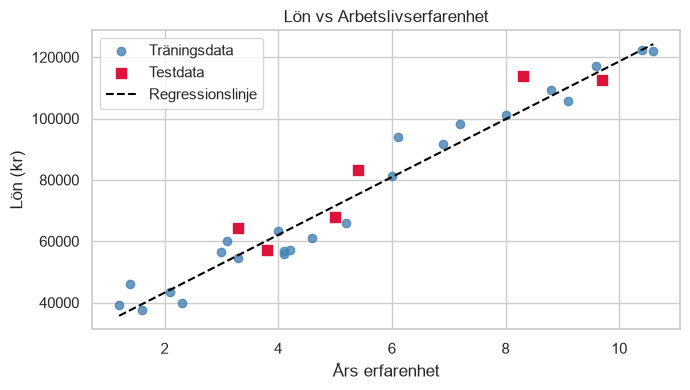

In [5]:
# Fråga 10: Korsvalidering på salary_dataset.csv
from sklearn.model_selection import cross_validate

# 1. Läs in datan
df_salary = pd.read_csv("data/salary_dataset.csv")
if "Unnamed: 0" in df_salary.columns:
    df_salary = df_salary.drop(columns=["Unnamed: 0"])

X_sal = df_salary[["YearsExperience"]]
y_sal = df_salary["Salary"]

# 2. Dela i träning och test (80/20)
X_sal_train, X_sal_test, y_sal_train, y_sal_test = train_test_split(
    X_sal, y_sal, test_size=0.2, random_state=42
)

# 3. Korsvalidering med 5 folds
candidate_models = {
    "Linjär Regression": LinearRegression(),
    "Beslutsträd (max_depth=3)": DecisionTreeRegressor(max_depth=3, random_state=42)
}

print("Korsvalideringsresultat (cv=5, neg_root_mean_squared_error):")
cv_scores = {}
for name, mod in candidate_models.items():
    res = cross_validate(mod, X_sal_train, y_sal_train, cv=5, scoring="neg_root_mean_squared_error")
    # Vänd tecknet för att få positivt RMSE
    rmse_folds = -res["test_score"]
    cv_scores[name] = rmse_folds
    print(f"  {name:25s}: Snitt-RMSE = {rmse_folds.mean():.2f} kr (std: {rmse_folds.std():.2f})")

# 4. Träna Linjär regression på hela träningssetet och testa på testsetet
sal_model = LinearRegression().fit(X_sal_train, y_sal_train)
sal_test_rmse = root_mean_squared_error(y_sal_test, sal_model.predict(X_sal_test))
print(f"\nSlutligt Test-RMSE (Linjär Regression): {sal_test_rmse:.2f} kr")

# 5. Visualisera resultatet
plt.figure(figsize=(7, 4))
plt.scatter(X_sal_train, y_sal_train, color="steelblue", label="Träningsdata", alpha=0.8)
plt.scatter(X_sal_test, y_sal_test, color="crimson", marker="s", s=60, label="Testdata")

x_grid = np.linspace(X_sal["YearsExperience"].min(), X_sal["YearsExperience"].max(), 100).reshape(-1, 1)
plt.plot(x_grid, sal_model.predict(x_grid), color="black", linestyle="--", label="Regressionslinje")

plt.title("Lön vs Arbetslivserfarenhet")
plt.xlabel("Års erfarenhet")
plt.ylabel("Lön (kr)")
plt.legend()
plt.tight_layout()
plt.show()


### Fråga 11 (Koduppgift): Multipel regression och kategorisk data på `mpg`

Här hanterar vi Seaborns dataset `mpg`:
- Droppar rader med saknade värden (`dropna()`).
- Tar bort kolumnen `name` (som har unika modellnamn och inte lämpar sig för regression).
- Källvariabeln `origin` konverteras till dummyvariabler med `pd.get_dummies(..., drop_first=True)` för att undvika multikollinearitet.
- Delar upp i träning och test (80/20).
- Tränar en multipel linjär regressionsmodell och utvärderar med RMSE och $R^2$.


In [6]:
# Fråga 11: Multipel linjär regression på mpg
from sklearn.metrics import r2_score

# 1. Hämta datasetet från Seaborn
df_mpg = sns.load_dataset("mpg")
print(f"Rådatans form: {df_mpg.shape}")

# 2. Droppa saknade värden och kolumnen 'name'
df_mpg = df_mpg.dropna().drop(columns=["name"])
print(f"Efter dropna() och borttagning av 'name': {df_mpg.shape}")

# 3. Dummy encoding på kategoriska 'origin' med drop_first=True
df_mpg = pd.get_dummies(df_mpg, columns=["origin"], drop_first=True, dtype=int)
print(f"Kolumner efter dummy-encoding: {list(df_mpg.columns)}")

# 4. Dela i features (X) och target (y = mpg)
X_mpg = df_mpg.drop(columns=["mpg"])
y_mpg = df_mpg["mpg"]

# 5. Train/test split (80/20)
X_tr_mpg, X_te_mpg, y_tr_mpg, y_te_mpg = train_test_split(
    X_mpg, y_mpg, test_size=0.2, random_state=42
)

# 6. Träna linjär regression
lr_mpg = LinearRegression().fit(X_tr_mpg, y_tr_mpg)
y_pred_mpg = lr_mpg.predict(X_te_mpg)

# 7. Utvärdera
rmse_mpg = root_mean_squared_error(y_te_mpg, y_pred_mpg)
r2_mpg = r2_score(y_te_mpg, y_pred_mpg)

print(f"\nResultat på testdata:")
print(f"  Test-RMSE: {rmse_mpg:.3f} miles per gallon")
print(f"  Test-R²:   {r2_mpg:.3f} (modellen förklarar ca {r2_mpg*100:.1f}% av variansen)")


Rådatans form: (398, 9)
Efter dropna() och borttagning av 'name': (392, 8)
Kolumner efter dummy-encoding: ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin_japan', 'origin_usa']

Resultat på testdata:
  Test-RMSE: 3.256 miles per gallon
  Test-R²:   0.792 (modellen förklarar ca 79.2% av variansen)


### Fråga 12 (Koduppgift): Förbättra California Housing-modellen

I boken nådde baslinjemodellen (Random Forest) ett **validerings-RMSE på ~52 278 dollar**.  
Målet är att slå detta baslinjeresultat genom:
1. **Feature Engineering:**
   - `rooms_per_household = total_rooms / households`
   - `bedrooms_per_room = total_bedrooms / total_rooms`
   - `population_per_household = population / households`
2. **Robust förbehandling med scikit-learn Pipeline och ColumnTransformer:**
   - Imputering av saknade medianvärden med `SimpleImputer(strategy="median")`.
   - Standardisering av numeriska funktioner med `StandardScaler()`.
   - One-hot encoding av `ocean_proximity` med `OneHotEncoder(drop="first")`.
3. **Optimerad Random Forest:**
   - `n_estimators=150`, `max_features=0.6` och `min_samples_split=4` för att motverka överanpassning och ge bättre generalisering.


In [7]:
# Fråga 12: Förbättring av California Housing-modellen
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 1. Läs in housing-datan
df_housing = pd.read_csv("data/housing.csv")

# 2. Feature Engineering
df_housing["rooms_per_household"] = df_housing["total_rooms"] / df_housing["households"]
df_housing["bedrooms_per_room"] = df_housing["total_bedrooms"] / df_housing["total_rooms"]
df_housing["population_per_household"] = df_housing["population"] / df_housing["households"]

# 3. Dela i X och y
X_housing = df_housing.drop(columns=["median_house_value"])
y_housing = df_housing["median_house_value"]

# 4. Dela i train (80%) och validation (20%) enligt bokens uppdelning
X_h_train, X_h_val, y_h_train, y_h_val = train_test_split(
    X_housing, y_housing, test_size=0.2, random_state=42
)

# 5. Definiera kolumntyper
num_features = [col for col in X_housing.columns if col != "ocean_proximity"]
cat_features = ["ocean_proximity"]

# 6. Bygg förbehandlingspipeline
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, num_features),
    ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_features)
])

# 7. Sätt ihop med Random Forest i en samlad pipeline
rf_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("rf", RandomForestRegressor(
        n_estimators=150,
        max_features=0.6,
        min_samples_split=4,
        random_state=42,
        n_jobs=-1
    ))
])

# 8. Träna modellen
print("Tränar optimerad Random Forest...")
rf_pipe.fit(X_h_train, y_h_train)

# 9. Utvärdera på valideringsdatan
val_preds = rf_pipe.predict(X_h_val)
improved_rmse = root_mean_squared_error(y_h_val, val_preds)

print("=" * 60)
print(f"Bokens baslinje-RMSE (Random Forest): ~52 278 dollar")
print(f"Vår förbättrade modells RMSE:         {improved_rmse:.2f} dollar")
print(f"Förbättring:                         {52278 - improved_rmse:.2f} dollar lägre fel!")
print("=" * 60)


Tränar optimerad Random Forest...


Bokens baslinje-RMSE (Random Forest): ~52 278 dollar
Vår förbättrade modells RMSE:         48915.45 dollar
Förbättring:                         3362.55 dollar lägre fel!
